In [7]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

# Change this path only if your files are in another folder
DATA_DIR = Path("/content")

file_paths = [
    DATA_DIR / "combined_schema_1.csv",
    DATA_DIR / "combined_schema_2.csv",
    DATA_DIR / "combined_schema_3.csv"
]

file_paths

[PosixPath('/content/combined_schema_1.csv'),
 PosixPath('/content/combined_schema_2.csv'),
 PosixPath('/content/combined_schema_3.csv')]

In [8]:
def read_csv_safely(path):
    """
    Reads CSV files safely even if encoding is German/Latin-based.
    """
    for enc in ["utf-8", "utf-8-sig", "latin1", "cp1252"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue

    return pd.read_csv(path, encoding="latin1", low_memory=False)


def clean_text(x):
    """
    Basic text cleaning.
    """
    if pd.isna(x):
        return np.nan
    return str(x).strip()


def clean_key_text(x):
    """
    Standardizes ID text for matching.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x


def parse_german_number(x):
    """
    Converts German numeric format into float.
    Example:
    '1.234.567,89' -> 1234567.89
    '-25.454,00' -> -25454.00
    """
    if pd.isna(x):
        return np.nan

    if isinstance(x, (int, float, np.number)):
        return float(x)

    s = str(x).strip()

    if s == "" or s.lower() in ["nan", "none", "-", "—"]:
        return np.nan

    s = s.replace("€", "").replace("CHF", "").replace("%", "").strip()
    s = s.replace("\u00a0", "").replace(" ", "")

    negative = False
    if s.startswith("(") and s.endswith(")"):
        negative = True
        s = s[1:-1]

    # German number format
    if "," in s:
        s = s.replace(".", "").replace(",", ".")

    try:
        value = float(s)
        return -value if negative else value
    except:
        return np.nan


def extract_year(x):
    """
    Extracts year from Finanzkennzahlen Datum.
    """
    if pd.isna(x):
        return np.nan

    dt = pd.to_datetime(x, errors="coerce", dayfirst=True)

    if pd.notna(dt):
        return int(dt.year)

    match = re.search(r"(20\d{2}|19\d{2})", str(x))
    if match:
        return int(match.group(1))

    return np.nan

In [9]:
frames = []

for fp in file_paths:
    if fp.exists():
        temp = read_csv_safely(fp)
        temp["source_file"] = fp.name
        frames.append(temp)
        print(f"Loaded: {fp.name} | Rows: {len(temp):,}")
    else:
        print(f"File not found: {fp}")

raw = pd.concat(frames, ignore_index=True, sort=False)

print("\nTotal rows loaded:", f"{len(raw):,}")
print("Total columns:", raw.shape[1])

raw.head()

Loaded: combined_schema_1.csv | Rows: 38,216
Loaded: combined_schema_2.csv | Rows: 98,189
Loaded: combined_schema_3.csv | Rows: 5,910

Total rows loaded: 142,315
Total columns: 68


,Name,Rechtsform,Land,PLZ,Ort,Straße,HR Amtsgericht,Register-ID,Status,North Data URL,Tel.,Fax,E-Mail,Website,USt.-Id.,Eintragung,Eintragung Datum,Branche (WZ),Ges. Vertreter 1,Ges. Vertreter 2,Ges. Vertreter 3,Gegenstand,Tickers,Finanzkennzahlen Datum,Stamm-/Grundkapital CHF,Bilanzsumme CHF,Gewinn CHF,Gewinn CAGR %,Umsatz CHF,Umsatz CAGR %,Umsatzrendite %,Eigenkapital CHF,EK-Quote %,EK-Rendite %,Mitarbeiterzahl,Umsatz pro Mitarbeiter CHF,Steuern CHF,Steuer-Quote %,Kassenbestand CHF,Forderungen CHF,Verbindlichkeiten CHF,Materialaufwand CHF,Personalaufwand CHF,Personalaufwand pro Mitarbeiter CHF,Pensionsrückstellungen CHF,Immobilien und Grundstücke CHF,Mktg&Tech Bezugszeitraum,Anzahl Förderungen pro Jahr,Gesamtfördersumme pro Jahr CHF,Patente pro Jahr,Marken pro Jahr,source_file,Stamm-/Grundkapital EUR,Bilanzsumme EUR,Gewinn EUR,Umsatz EUR,Eigenkapital EUR,Umsatz pro Mitarbeiter EUR,Steuern EUR,Kassenbestand EUR,Forderungen EUR,Verbindlichkeiten EUR,Materialaufwand EUR,Personalaufwand EUR,Personalaufwand pro Mitarbeiter EUR,Pensionsrückstellungen EUR,Immobilien und Grundstücke EUR,Gesamtfördersumme pro Jahr EUR
0,Punktzona GmbH,GmbH,CH,8001.0,Zürich,Rindermarkt 17,NaN,CHE-367.699.558,aktiv,"https://www.northdata.de/Punktzona%20GmbH,%20Z...",+41 442626280,NaN,info@punktzona.ch,http://www.punktzona.ch/,CHE367699558,Eintragung,20.02.2012,71.11.2 Büros für Innenarchitektur,"Tomaschett, Sibylle","Heuberger, Beat Bernhard",NaN,Die Gesellschaft bezweckt die Erbringung von D...,NaN,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,combined_schema_1.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mirlo Urbano Architekten GmbH,GmbH,CH,8005.0,Zürich,Ausstellungsstrasse 21,NaN,CHE-387.028.309,aktiv,https://www.northdata.de/Mirlo%20Urbano%20Arch...,+41 445330474,NaN,NaN,NaN,CHE387028309,Eintragung,11.10.2011,"71.11.3 Architekturbüros für Orts-, Regional- ...","Amsler, Matthias Philipp","Stettler, Fabian",NaN,Zweck der Gesellschaft ist die Erbringung von ...,NaN,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,combined_schema_1.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SPPA Architekten AG,AG,CH,8001.0,Zürich,Sihlamtsstrasse 10,NaN,CHE-428.722.651,aktiv,https://www.northdata.de/SPPA%20Architekten%20...,+41 442157070,+41 442157071,info@sppa.ch,https://www.sppa.ch/,CHE428722651,Eintragung,25.07.2011,"71.11.3 Architekturbüros für Orts-, Regional- ...","Trachsler, Peter Daniel","Graf, Beat","Häberli Ghirardi, Hans Peter",Die Gesellschaft bezweckt den Betrieb eines Pl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,combined_schema_1.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Jenni Architektur und Städtebau,NaN,CH,8004.0,Zürich,Rotwandstrasse 39,NaN,CHE-281.113.301,aktiv,https://www.northdata.de/Jenni%20Architektur%2...,+41 442911718,NaN,NaN,http://www.jenniarchitektur.ch/,CHE281113301,Eintragung,16.03.2012,"71.11.3 Architekturbüros für Orts-, Regional- ...","Jenni, Peter",NaN,NaN,"Dienstleistungen im Bereich Architektur, Städt...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,combined_schema_1.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,starch.GmbH,GmbH,CH,8004.0,Zürich,Tellstrasse 4,NaN,CHE-256.694.510,aktiv,"https://www.northdata.de/starch%C2%B7GmbH,%20Z...",+41 433220934,NaN,NaN,NaN,CHE256694510,Eintragung,25.11.2011,71.12.1 Ingenieurbüros für bautechnische Gesam...,"Stierlin, Marc","Stierlin-Vogler, Maja",NaN,Die Gesellschaft bezweckt den Betrieb eines Ar...,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,combined_schema_1.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Clean main identity columns
main_text_cols = [
    "Name", "Land", "Ort", "HR Amtsgericht", "Register-ID",
    "Status", "Branche (WZ)", "Finanzkennzahlen Datum", "North Data URL"
]

for col in main_text_cols:
    if col in raw.columns:
        raw[col] = raw[col].apply(clean_text)

# Extract year
raw["year"] = raw["Finanzkennzahlen Datum"].apply(extract_year)

# Strict company ID
# This is the main legal matching key:
# HR Amtsgericht + Register-ID
raw["company_id"] = (
    raw["HR Amtsgericht"].apply(clean_key_text).str.lower()
    + "|"
    + raw["Register-ID"].apply(clean_key_text).str.upper()
)

# Keep only rows where strict ID and year exist
panel_base = raw[
    raw["company_id"].notna()
    & raw["HR Amtsgericht"].notna()
    & raw["Register-ID"].notna()
    & raw["year"].notna()
].copy()

panel_base["year"] = panel_base["year"].astype(int)

print("Rows with valid company ID and financial year:", f"{len(panel_base):,}")
print("Unique strict company IDs:", f"{panel_base['company_id'].nunique():,}")
print("Financial year range:", panel_base["year"].min(), "to", panel_base["year"].max())

panel_base[["Name", "HR Amtsgericht", "Register-ID", "company_id", "Finanzkennzahlen Datum", "year"]].head()

Rows with valid company ID and financial year: 98,879
Unique strict company IDs: 91,013
Financial year range: 2006 to 2025


,Name,HR Amtsgericht,Register-ID,company_id,Finanzkennzahlen Datum,year
38216,Knut Rösch Baugrunduntersuchungen GmbH,Kiel,HRB 7129 KI,kiel|HRB 7129 KI,31.12.2024,2024
38217,Soulworks Developments GmbH,München,HRB 288800,münchen|HRB 288800,31.12.2022,2022
38218,BEHR INGENIEURE GmbH,Leipzig,HRB 11586,leipzig|HRB 11586,31.12.2023,2023
38219,GLASFAKTOR Ingenieure GmbH,Dresden,HRB 30711,dresden|HRB 30711,30.11.2023,2023
38220,Novum Analytik GmbH,Stuttgart,HRB 723862,stuttgart|HRB 723862,31.12.2023,2023


In [11]:
numeric_cols = [
    "Stamm-/Grundkapital EUR",
    "Bilanzsumme EUR",
    "Gewinn EUR",
    "Umsatz EUR",
    "Eigenkapital EUR",
    "Kassenbestand EUR",
    "Forderungen EUR",
    "Verbindlichkeiten EUR",
    "Mitarbeiterzahl",
    "Umsatzrendite %",
    "EK-Quote %",
    "EK-Rendite %",
    "Personalaufwand EUR",
    "Materialaufwand EUR",
    "Steuern EUR"
]

for col in numeric_cols:
    if col in panel_base.columns:
        panel_base[col + "_num"] = panel_base[col].apply(parse_german_number)
    else:
        panel_base[col + "_num"] = np.nan

num_clean_cols = [col + "_num" for col in numeric_cols]

panel_base[num_clean_cols].head()

,Stamm-/Grundkapital EUR_num,Bilanzsumme EUR_num,Gewinn EUR_num,Umsatz EUR_num,Eigenkapital EUR_num,Kassenbestand EUR_num,Forderungen EUR_num,Verbindlichkeiten EUR_num,Mitarbeiterzahl_num,Umsatzrendite %_num,EK-Quote %_num,EK-Rendite %_num,Personalaufwand EUR_num,Materialaufwand EUR_num,Steuern EUR_num
38216,26.0,679793.84,-113496.26,690.0,200063.46,150845.95,59624.39,358115.38,NaN,-16.45,29.43,-56.73,NaN,NaN,NaN
38217,25.0,679593.17,-217337.80,NaN,619387.88,333451.04,331284.83,29415.29,NaN,-5.05,91.14,-35.09,NaN,NaN,NaN
38218,25.6,679558.80,133323.10,NaN,156773.48,425336.85,181877.25,162438.70,12.0,12.12,23.07,85.04,NaN,NaN,NaN
38219,25.0,679529.43,216008.68,NaN,501018.27,619318.74,49954.88,136972.16,NaN,19.64,73.73,43.11,NaN,NaN,NaN
38220,25.0,679420.19,6529.39,NaN,534165.84,162635.85,191789.74,112454.35,13.0,0.20,78.62,1.22,NaN,NaN,NaN


In [12]:
# Some company-year rows may be duplicated.
# We keep the row with the highest number of available financial values.

panel_base["nonmissing_financial_count"] = panel_base[num_clean_cols].notna().sum(axis=1)

panel_year = (
    panel_base
    .sort_values(
        ["company_id", "year", "nonmissing_financial_count"],
        ascending=[True, True, False]
    )
    .drop_duplicates(["company_id", "year"], keep="first")
    .copy()
)

# Count number of years per company
company_year_count = (
    panel_year
    .groupby("company_id")["year"]
    .nunique()
    .reset_index(name="n_years")
)

multi_year_ids = company_year_count.loc[
    company_year_count["n_years"] > 1, "company_id"
]

panel40 = panel_year[panel_year["company_id"].isin(multi_year_ids)].copy()

print("Unique company-year rows after duplicate removal:", f"{len(panel_year):,}")
print("Companies with more than one year:", panel40["company_id"].nunique())
print("Total rows in 40-company panel:", len(panel40))

display(
    panel40.groupby("company_id")["year"]
    .agg(["min", "max", "nunique"])
    .reset_index()
    .rename(columns={"min": "first_year", "max": "last_year", "nunique": "number_of_years"})
    .head()
)

Unique company-year rows after duplicate removal: 91,053
Companies with more than one year: 40
Total rows in 40-company panel: 80


,company_id,first_year,last_year,number_of_years
0,bayreuth|HRB 4745,2023,2024,2
1,bremen|HRA 30096,2021,2024,2
2,charlottenburg (berlin)|HRA 58376 B,2022,2024,2
3,charlottenburg (berlin)|HRB 57136 B,2023,2024,2
4,charlottenburg (berlin)|HRB 90118 B,2023,2024,2


In [13]:
year_pairs = (
    panel40
    .groupby("company_id")["year"]
    .agg(first_year="min", last_year="max", number_of_years="nunique")
    .reset_index()
)

year_pairs["year_pair"] = (
    year_pairs["first_year"].astype(str)
    + "-"
    + year_pairs["last_year"].astype(str)
)

year_pair_summary = (
    year_pairs["year_pair"]
    .value_counts()
    .reset_index()
)

year_pair_summary.columns = ["year_pair", "number_of_companies"]

display(year_pair_summary)

,year_pair,number_of_companies
0,2023-2024,30
1,2022-2024,3
2,2022-2023,3
3,2024-2025,2
4,2021-2024,1
5,2021-2023,1


In [14]:
p = panel40.copy()

# Profitability ratios
p["profit_margin_calc_pct"] = np.where(
    p["Umsatz EUR_num"].abs() > 0,
    p["Gewinn EUR_num"] / p["Umsatz EUR_num"] * 100,
    np.nan
)

p["roa_calc_pct"] = np.where(
    p["Bilanzsumme EUR_num"].abs() > 0,
    p["Gewinn EUR_num"] / p["Bilanzsumme EUR_num"] * 100,
    np.nan
)

p["roe_calc_pct"] = np.where(
    p["Eigenkapital EUR_num"].abs() > 0,
    p["Gewinn EUR_num"] / p["Eigenkapital EUR_num"] * 100,
    np.nan
)

# Efficiency ratio
p["asset_turnover_calc"] = np.where(
    p["Bilanzsumme EUR_num"].abs() > 0,
    p["Umsatz EUR_num"] / p["Bilanzsumme EUR_num"],
    np.nan
)

# Financial position ratios
p["equity_ratio_calc_pct"] = np.where(
    p["Bilanzsumme EUR_num"].abs() > 0,
    p["Eigenkapital EUR_num"] / p["Bilanzsumme EUR_num"] * 100,
    np.nan
)

p["debt_ratio_calc_pct"] = np.where(
    p["Bilanzsumme EUR_num"].abs() > 0,
    p["Verbindlichkeiten EUR_num"] / p["Bilanzsumme EUR_num"] * 100,
    np.nan
)

p["cash_to_assets_calc_pct"] = np.where(
    p["Bilanzsumme EUR_num"].abs() > 0,
    p["Kassenbestand EUR_num"] / p["Bilanzsumme EUR_num"] * 100,
    np.nan
)

p["receivables_to_assets_calc_pct"] = np.where(
    p["Bilanzsumme EUR_num"].abs() > 0,
    p["Forderungen EUR_num"] / p["Bilanzsumme EUR_num"] * 100,
    np.nan
)

p["liabilities_to_equity_calc"] = np.where(
    p["Eigenkapital EUR_num"].abs() > 0,
    p["Verbindlichkeiten EUR_num"] / p["Eigenkapital EUR_num"],
    np.nan
)

# Employee productivity
p["sales_per_employee_calc"] = np.where(
    p["Mitarbeiterzahl_num"].abs() > 0,
    p["Umsatz EUR_num"] / p["Mitarbeiterzahl_num"],
    np.nan
)

p["profit_per_employee_calc"] = np.where(
    p["Mitarbeiterzahl_num"].abs() > 0,
    p["Gewinn EUR_num"] / p["Mitarbeiterzahl_num"],
    np.nan
)

panel40_ratios = p.copy()

display(
    panel40_ratios[
        [
            "Name", "HR Amtsgericht", "Register-ID", "year",
            "Umsatz EUR_num", "Gewinn EUR_num",
            "profit_margin_calc_pct", "roa_calc_pct",
            "equity_ratio_calc_pct", "debt_ratio_calc_pct"
        ]
    ].head(10)
)

,Name,HR Amtsgericht,Register-ID,year,Umsatz EUR_num,Gewinn EUR_num,profit_margin_calc_pct,roa_calc_pct,equity_ratio_calc_pct,debt_ratio_calc_pct
131968,P & S Vermögensberatungs AG Performance & Sich...,Bayreuth,HRB 4745,2023,NaN,NaN,NaN,NaN,NaN,NaN
84030,P & S Vermögensberatungs AG Performance & Sich...,Bayreuth,HRB 4745,2024,NaN,NaN,NaN,NaN,NaN,NaN
131588,DNL Prime Invest I. GmbH & Co. geschlossene In...,Bremen,HRA 30096,2021,NaN,NaN,NaN,NaN,NaN,NaN
59062,DNL Prime Invest I. GmbH & Co. geschlossene In...,Bremen,HRA 30096,2024,146042.73,725766.72,496.955049,9.109587,70.156959,100.000000
68781,DFI Wohnen 1 geschlossene Investment GmbH & Co...,Charlottenburg (Berlin),HRA 58376 B,2022,NaN,NaN,NaN,NaN,96.333295,NaN
84408,DFI Wohnen 1 geschlossene Investment GmbH & Co...,Charlottenburg (Berlin),HRA 58376 B,2024,523200.00,506.40,0.096789,NaN,NaN,NaN
89558,Alphabet Immobilien AG,Charlottenburg (Berlin),HRB 57136 B,2023,NaN,NaN,NaN,NaN,NaN,NaN
113851,Alphabet Immobilien AG,Charlottenburg (Berlin),HRB 57136 B,2024,NaN,1333323.77,NaN,4.335301,86.527166,13.472834
48690,JS Stahlbau GmbH,Charlottenburg (Berlin),HRB 90118 B,2023,NaN,94857.39,NaN,26.600653,56.957098,30.937416
38793,JS Stahlbau GmbH,Charlottenburg (Berlin),HRB 90118 B,2024,NaN,62146.88,NaN,8.322900,35.523727,57.457367


In [15]:
analysis_ratio_cols = [
    "Bilanzsumme EUR_num",
    "Umsatz EUR_num",
    "Gewinn EUR_num",
    "Eigenkapital EUR_num",
    "Kassenbestand EUR_num",
    "Forderungen EUR_num",
    "Verbindlichkeiten EUR_num",
    "Mitarbeiterzahl_num",
    "profit_margin_calc_pct",
    "roa_calc_pct",
    "roe_calc_pct",
    "asset_turnover_calc",
    "equity_ratio_calc_pct",
    "debt_ratio_calc_pct",
    "cash_to_assets_calc_pct",
    "receivables_to_assets_calc_pct",
    "liabilities_to_equity_calc",
    "sales_per_employee_calc",
    "profit_per_employee_calc"
]

ratio_availability = []

for col in analysis_ratio_cols:
    available_rows = panel40_ratios[col].notna().sum()
    available_companies = (
        panel40_ratios.loc[panel40_ratios[col].notna(), "company_id"]
        .nunique()
    )

    ratio_availability.append({
        "variable": col,
        "available_rows": available_rows,
        "available_companies": available_companies,
        "row_availability_pct": available_rows / len(panel40_ratios) * 100,
        "company_availability_pct": available_companies / panel40_ratios["company_id"].nunique() * 100
    })

ratio_availability = pd.DataFrame(ratio_availability)

display(ratio_availability.sort_values("available_companies", ascending=False))

,variable,available_rows,available_companies,row_availability_pct,company_availability_pct
0,Bilanzsumme EUR_num,61,37,76.25,92.5
2,Gewinn EUR_num,57,37,71.25,92.5
3,Eigenkapital EUR_num,59,37,73.75,92.5
6,Verbindlichkeiten EUR_num,61,37,76.25,92.5
5,Forderungen EUR_num,59,37,73.75,92.5
13,debt_ratio_calc_pct,59,36,73.75,90.0
4,Kassenbestand EUR_num,56,36,70.00,90.0
12,equity_ratio_calc_pct,58,36,72.50,90.0
15,receivables_to_assets_calc_pct,57,36,71.25,90.0
16,liabilities_to_equity_calc,56,35,70.00,87.5


In [16]:
id_cols = [
    "company_id",
    "Name",
    "Land",
    "Ort",
    "HR Amtsgericht",
    "Register-ID",
    "Status",
    "Branche (WZ)"
]

change_cols = analysis_ratio_cols

# First observation per company
first_obs = (
    panel40_ratios
    .sort_values(["company_id", "year"])
    .groupby("company_id")
    .first()
    .reset_index()
)

# Last observation per company
last_obs = (
    panel40_ratios
    .sort_values(["company_id", "year"])
    .groupby("company_id")
    .last()
    .reset_index()
)

change_df = first_obs[id_cols].copy()

change_df["first_year"] = first_obs["year"]
change_df["last_year"] = last_obs["year"]
change_df["year_gap"] = change_df["last_year"] - change_df["first_year"]

for col in change_cols:
    change_df[col + "_first"] = first_obs[col]
    change_df[col + "_last"] = last_obs[col]
    change_df[col + "_change"] = last_obs[col] - first_obs[col]

    change_df[col + "_pct_change"] = np.where(
        first_obs[col].abs() > 0,
        (last_obs[col] - first_obs[col]) / first_obs[col].abs() * 100,
        np.nan
    )

display(
    change_df[
        [
            "Name", "HR Amtsgericht", "Register-ID",
            "first_year", "last_year", "year_gap",
            "Umsatz EUR_num_first", "Umsatz EUR_num_last", "Umsatz EUR_num_change",
            "Gewinn EUR_num_first", "Gewinn EUR_num_last", "Gewinn EUR_num_change"
        ]
    ].head(10)
)

,Name,HR Amtsgericht,Register-ID,first_year,last_year,year_gap,Umsatz EUR_num_first,Umsatz EUR_num_last,Umsatz EUR_num_change,Gewinn EUR_num_first,Gewinn EUR_num_last,Gewinn EUR_num_change
0,P & S Vermögensberatungs AG Performance & Sich...,Bayreuth,HRB 4745,2023,2024,1,NaN,NaN,NaN,NaN,NaN,NaN
1,DNL Prime Invest I. GmbH & Co. geschlossene In...,Bremen,HRA 30096,2021,2024,3,146042.73,146042.73,0.0,725766.72,725766.72,0.00
2,DFI Wohnen 1 geschlossene Investment GmbH & Co...,Charlottenburg (Berlin),HRA 58376 B,2022,2024,2,523200.00,523200.00,0.0,506.40,506.40,0.00
3,Alphabet Immobilien AG,Charlottenburg (Berlin),HRB 57136 B,2023,2024,1,NaN,NaN,NaN,1333323.77,1333323.77,0.00
4,JS Stahlbau GmbH,Charlottenburg (Berlin),HRB 90118 B,2023,2024,1,NaN,NaN,NaN,94857.39,62146.88,-32710.51
5,Novoferm Spare Parts GmbH,Coesfeld,HRB 13895,2023,2024,1,NaN,NaN,NaN,528.00,528.00,0.00
6,LaDar 1 Holding GmbH,Cottbus,HRB 15674,2023,2024,1,NaN,NaN,NaN,NaN,NaN,NaN
7,Thermisches Beschichtungscenter Uskovic GmbH,Dortmund,HRB 28949,2023,2024,1,NaN,NaN,NaN,150747.21,211875.24,61128.03
8,OK Asset Management GmbH,Düsseldorf,HRB 100567,2023,2024,1,NaN,NaN,NaN,2915795.76,2915795.76,0.00
9,Emscher Wassertechnik GmbH,Essen,HRB 11082,2023,2024,1,NaN,NaN,NaN,2448106.38,2694601.31,246494.93


In [17]:
summary_variables = {
    "Revenue": "Umsatz EUR_num_change",
    "Profit": "Gewinn EUR_num_change",
    "Total assets": "Bilanzsumme EUR_num_change",
    "Equity": "Eigenkapital EUR_num_change",
    "Cash": "Kassenbestand EUR_num_change",
    "Liabilities": "Verbindlichkeiten EUR_num_change",
    "Profit margin": "profit_margin_calc_pct_change",
    "ROA": "roa_calc_pct_change",
    "ROE": "roe_calc_pct_change",
    "Asset turnover": "asset_turnover_calc_change",
    "Equity ratio": "equity_ratio_calc_pct_change",
    "Debt ratio": "debt_ratio_calc_pct_change",
    "Cash/assets": "cash_to_assets_calc_pct_change",
    "Receivables/assets": "receivables_to_assets_calc_pct_change"
}

change_summary = []

for label, col in summary_variables.items():
    valid = change_df[col].dropna()

    change_summary.append({
        "variable": label,
        "companies_with_data": len(valid),
        "improved_or_increased": (valid > 0).sum(),
        "declined_or_decreased": (valid < 0).sum(),
        "unchanged": (valid == 0).sum(),
        "mean_change": valid.mean(),
        "median_change": valid.median(),
        "min_change": valid.min(),
        "max_change": valid.max()
    })

change_summary = pd.DataFrame(change_summary)

display(change_summary)

,variable,companies_with_data,improved_or_increased,declined_or_decreased,unchanged,mean_change,median_change,min_change,max_change
0,Revenue,13,3,0,10,2.807897e+05,0.0,0.000000e+00,2.403858e+06
1,Profit,37,10,8,19,9.436359e+04,0.0,-3.360236e+05,1.254411e+06
2,Total assets,37,18,6,13,3.692821e+06,0.0,-2.273397e+06,7.674940e+07
3,Equity,37,16,4,17,4.502977e+05,0.0,-1.078398e+05,4.506207e+06
4,Cash,36,13,7,16,2.522779e+05,0.0,-8.865238e+05,4.874360e+06
5,Liabilities,37,14,10,13,1.424649e+07,0.0,-3.698432e+06,4.685680e+08
6,Profit margin,13,1,1,11,2.965606e-01,0.0,-5.817783e-02,3.913466e+00
7,ROA,35,9,9,17,4.241024e-01,0.0,-2.033727e+01,6.393323e+01
8,ROE,34,6,11,17,5.010821e+04,0.0,-9.121927e+01,1.703743e+06
9,Asset turnover,12,3,0,9,1.366661e-02,0.0,0.000000e+00,1.068731e-01


In [18]:
score_df = change_df.copy()

# Profitability improvement
score_df["profit_improved"] = score_df["Gewinn EUR_num_change"] > 0
score_df["profit_margin_improved"] = score_df["profit_margin_calc_pct_change"] > 0
score_df["roa_improved"] = score_df["roa_calc_pct_change"] > 0

# Financial position improvement
score_df["equity_ratio_improved"] = score_df["equity_ratio_calc_pct_change"] > 0
score_df["debt_ratio_improved"] = score_df["debt_ratio_calc_pct_change"] < 0

# Revenue growth
score_df["revenue_increased"] = score_df["Umsatz EUR_num_change"] > 0

score_components = [
    "profit_improved",
    "profit_margin_improved",
    "roa_improved",
    "equity_ratio_improved",
    "debt_ratio_improved",
    "revenue_increased"
]

score_df["improvement_score"] = score_df[score_components].sum(axis=1)

score_df["overall_change_category"] = pd.cut(
    score_df["improvement_score"],
    bins=[-1, 1, 3, 6],
    labels=["mostly_declined", "mixed_change", "mostly_improved"]
)

display(
    score_df[
        [
            "Name", "HR Amtsgericht", "Register-ID",
            "first_year", "last_year",
            "improvement_score", "overall_change_category",
            "Gewinn EUR_num_change",
            "profit_margin_calc_pct_change",
            "equity_ratio_calc_pct_change",
            "debt_ratio_calc_pct_change"
        ]
    ].sort_values("improvement_score", ascending=False)
)

,Name,HR Amtsgericht,Register-ID,first_year,last_year,improvement_score,overall_change_category,Gewinn EUR_num_change,profit_margin_calc_pct_change,equity_ratio_calc_pct_change,debt_ratio_calc_pct_change
24,Dorado Grundstücksverwaltungsgesellschaft mbH,Mainz,HRB 7619,2023,2024,5,mostly_improved,35822.87,-0.058178,6.395825,-0.848606
15,Hutley Germany GmbH,Hannover,HRB 208030,2024,2025,4,mostly_improved,1246439.37,NaN,9.085150,-9.050860
34,M & S Autohaus GmbH,Potsdam,HRB 7664,2023,2024,4,mostly_improved,47212.66,NaN,4.019109,-4.757616
35,eurovettura GmbH,Regensburg,HRB 16628,2022,2023,4,mostly_improved,413337.04,NaN,9.222745,-10.283358
9,Emscher Wassertechnik GmbH,Essen,HRB 11082,2023,2024,4,mostly_improved,246494.93,NaN,7.555073,-14.781114
19,Erwin Himmelseher Assekuranz-Vermittlung GmbH ...,Köln,HRA 12182,2023,2024,4,mostly_improved,1077101.26,3.913466,NaN,33.559880
32,Liebl Immobilien GmbH,Passau,HRB 9315,2023,2024,4,mostly_improved,269045.55,NaN,25.239195,-29.456841
7,Thermisches Beschichtungscenter Uskovic GmbH,Dortmund,HRB 28949,2023,2024,3,mixed_change,61128.03,NaN,8.969149,-11.383553
33,NORTEG GmbH,Pinneberg,HRB 14833 PI,2023,2024,3,mixed_change,1254411.18,NaN,4.635857,1.308005
29,Schütz Solar GmbH,Neuss,HRB 17420,2023,2024,2,mixed_change,-321376.48,0.000000,11.673074,-8.645466


In [19]:
category_summary = (
    score_df["overall_change_category"]
    .value_counts(dropna=False)
    .reset_index()
)

category_summary.columns = ["overall_change_category", "number_of_companies"]

display(category_summary)

,overall_change_category,number_of_companies
0,mostly_declined,26
1,mixed_change,7
2,mostly_improved,7


In [20]:
top_profit_improvement = (
    change_df[
        [
            "Name", "HR Amtsgericht", "Register-ID",
            "first_year", "last_year",
            "Gewinn EUR_num_first", "Gewinn EUR_num_last", "Gewinn EUR_num_change",
            "Umsatz EUR_num_first", "Umsatz EUR_num_last", "Umsatz EUR_num_change",
            "profit_margin_calc_pct_first", "profit_margin_calc_pct_last", "profit_margin_calc_pct_change"
        ]
    ]
    .dropna(subset=["Gewinn EUR_num_change"])
    .sort_values("Gewinn EUR_num_change", ascending=False)
)

print("Top 10 profit improvers")
display(top_profit_improvement.head(10))

print("Top 10 profit decliners")
display(top_profit_improvement.tail(10))

Top 10 profit improvers


,Name,HR Amtsgericht,Register-ID,first_year,last_year,Gewinn EUR_num_first,Gewinn EUR_num_last,Gewinn EUR_num_change,Umsatz EUR_num_first,Umsatz EUR_num_last,Umsatz EUR_num_change,profit_margin_calc_pct_first,profit_margin_calc_pct_last,profit_margin_calc_pct_change
33,NORTEG GmbH,Pinneberg,HRB 14833 PI,2023,2024,280981.34,1535392.52,1254411.18,NaN,NaN,NaN,NaN,NaN,NaN
15,Hutley Germany GmbH,Hannover,HRB 208030,2024,2025,-197717.44,1048721.93,1246439.37,NaN,NaN,NaN,NaN,NaN,NaN
19,Erwin Himmelseher Assekuranz-Vermittlung GmbH ...,Köln,HRA 12182,2023,2024,5602918.89,6680020.15,1077101.26,11181067.40,12364858.42,1183791.02,50.110769,54.024235,3.913466
35,eurovettura GmbH,Regensburg,HRB 16628,2022,2023,158874.43,572211.47,413337.04,NaN,NaN,NaN,NaN,NaN,NaN
32,Liebl Immobilien GmbH,Passau,HRB 9315,2023,2024,331510.18,600555.73,269045.55,NaN,NaN,NaN,NaN,NaN,NaN
9,Emscher Wassertechnik GmbH,Essen,HRB 11082,2023,2024,2448106.38,2694601.31,246494.93,NaN,NaN,NaN,NaN,NaN,NaN
30,Be_baut GmbH & Co. KG,Osnabrück,HRA 206094,2022,2024,0.00,170374.26,170374.26,416.65,416.65,0.00,40891.458058,40891.458058,0.000000
7,Thermisches Beschichtungscenter Uskovic GmbH,Dortmund,HRB 28949,2023,2024,150747.21,211875.24,61128.03,NaN,NaN,NaN,NaN,NaN,NaN
34,M & S Autohaus GmbH,Potsdam,HRB 7664,2023,2024,677599.09,724811.75,47212.66,NaN,NaN,NaN,NaN,NaN,NaN
24,Dorado Grundstücksverwaltungsgesellschaft mbH,Mainz,HRB 7619,2023,2024,2311384.66,2347207.53,35822.87,3801640.47,3864257.61,62617.14,60.799665,60.741487,-0.058178


Top 10 profit decliners


,Name,HR Amtsgericht,Register-ID,first_year,last_year,Gewinn EUR_num_first,Gewinn EUR_num_last,Gewinn EUR_num_change,Umsatz EUR_num_first,Umsatz EUR_num_last,Umsatz EUR_num_change,profit_margin_calc_pct_first,profit_margin_calc_pct_last,profit_margin_calc_pct_change
26,Grenke Investitionen Verwaltungs KGaA,Mannheim,HRB 201845,2023,2024,0.00,0.00,0.00,6.365615e+08,6.365615e+08,0.0,0.000000,0.000000,0.0
25,SCHMITT-Kreiselpumpen GmbH & Co. KG,Mannheim,HRA 360550,2024,2025,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN
27,MK Anlagentechnik GmbH,Mannheim,HRB 718712,2023,2024,-85693.67,-107839.83,-22146.16,NaN,NaN,NaN,NaN,NaN,NaN
4,JS Stahlbau GmbH,Charlottenburg (Berlin),HRB 90118 B,2023,2024,94857.39,62146.88,-32710.51,NaN,NaN,NaN,NaN,NaN,NaN
23,Christian Sauer UG,Lübeck,HRB 17035 HL,2023,2024,46845.76,4486.74,-42359.02,NaN,NaN,NaN,NaN,NaN,NaN
22,Uteg Präzisionswerkzeuge GmbH,Lemgo,HRB 6402,2023,2024,9837.86,-70331.60,-80169.46,NaN,NaN,NaN,NaN,NaN,NaN
39,Ziegler GmbH,Würzburg,HRB 2756,2023,2024,250244.69,74059.66,-176185.03,NaN,NaN,NaN,NaN,NaN,NaN
16,Stesatec GmbH,Ingolstadt,HRB 191270,2023,2024,3387167.11,3068223.19,-318943.92,NaN,NaN,NaN,NaN,NaN,NaN
29,Schütz Solar GmbH,Neuss,HRB 17420,2023,2024,963580.61,642204.13,-321376.48,7.900000e+02,7.900000e+02,0.0,81291.662025,81291.662025,0.0
28,Exorka GmbH,München,HRB 183637,2023,2024,305760.05,-30263.58,-336023.63,NaN,NaN,NaN,NaN,NaN,NaN


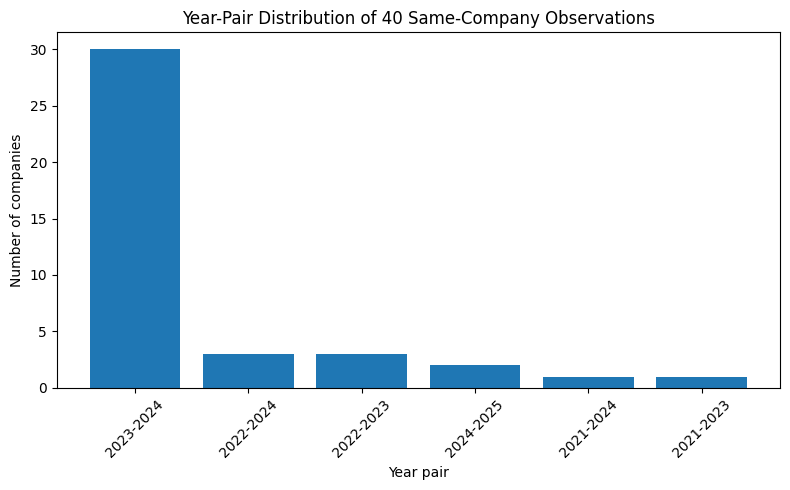

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(year_pair_summary["year_pair"], year_pair_summary["number_of_companies"])
plt.title("Year-Pair Distribution of 40 Same-Company Observations")
plt.xlabel("Year pair")
plt.ylabel("Number of companies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

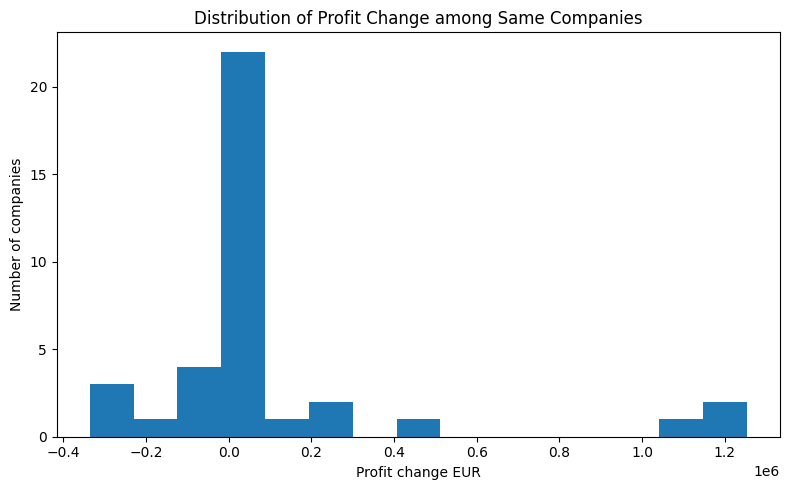

In [22]:
profit_change = change_df["Gewinn EUR_num_change"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(profit_change, bins=15)
plt.title("Distribution of Profit Change among Same Companies")
plt.xlabel("Profit change EUR")
plt.ylabel("Number of companies")
plt.tight_layout()
plt.show()

In [23]:
panel40_ratios.to_csv("06H_panel40_company_year_ratios.csv", index=False)
change_df.to_csv("06I_panel40_first_last_change_analysis.csv", index=False)
change_summary.to_csv("06J_panel40_change_summary.csv", index=False)
ratio_availability.to_csv("06K_panel40_ratio_availability.csv", index=False)
score_df.to_csv("06L_panel40_company_improvement_scores.csv", index=False)
year_pair_summary.to_csv("06M_panel40_year_pair_summary.csv", index=False)

print("Saved files:")
print("06H_panel40_company_year_ratios.csv")
print("06I_panel40_first_last_change_analysis.csv")
print("06J_panel40_change_summary.csv")
print("06K_panel40_ratio_availability.csv")
print("06L_panel40_company_improvement_scores.csv")
print("06M_panel40_year_pair_summary.csv")

Saved files:
06H_panel40_company_year_ratios.csv
06I_panel40_first_last_change_analysis.csv
06J_panel40_change_summary.csv
06K_panel40_ratio_availability.csv
06L_panel40_company_improvement_scores.csv
06M_panel40_year_pair_summary.csv


In [24]:
# We continue from previous output:
# change_df = first-year vs last-year change dataset
# score_df = same dataset with improvement_score and overall_change_category

driver_data = score_df.copy()

# Main target:
# improvement_score = how many important areas improved
target_col = "improvement_score"

# Ratio / financial change variables to test as possible drivers
candidate_drivers = {
    "Revenue change": "Umsatz EUR_num_change",
    "Profit change": "Gewinn EUR_num_change",
    "Profit margin change": "profit_margin_calc_pct_change",
    "ROA change": "roa_calc_pct_change",
    "ROE change": "roe_calc_pct_change",
    "Asset turnover change": "asset_turnover_calc_change",
    "Equity ratio change": "equity_ratio_calc_pct_change",
    "Debt ratio change": "debt_ratio_calc_pct_change",
    "Cash/assets change": "cash_to_assets_calc_pct_change",
    "Receivables/assets change": "receivables_to_assets_calc_pct_change",
    "Liabilities/equity change": "liabilities_to_equity_calc_change",
    "Sales per employee change": "sales_per_employee_calc_change",
    "Profit per employee change": "profit_per_employee_calc_change"
}

# Keep only variables actually available in the dataframe
candidate_drivers = {
    label: col for label, col in candidate_drivers.items()
    if col in driver_data.columns
}

print("Target variable:", target_col)
print("Number of available driver variables:", len(candidate_drivers))

list(candidate_drivers.keys())

Target variable: improvement_score
Number of available driver variables: 13


['Revenue change',
 'Profit change',
 'Profit margin change',
 'ROA change',
 'ROE change',
 'Asset turnover change',
 'Equity ratio change',
 'Debt ratio change',
 'Cash/assets change',
 'Receivables/assets change',
 'Liabilities/equity change',
 'Sales per employee change',
 'Profit per employee change']

In [25]:
from scipy.stats import spearmanr

driver_rankings = []

for label, col in candidate_drivers.items():
    temp = driver_data[[target_col, col]].dropna()

    if len(temp) >= 5:
        corr, p_value = spearmanr(temp[target_col], temp[col])
    else:
        corr, p_value = np.nan, np.nan

    driver_rankings.append({
        "driver": label,
        "column": col,
        "companies_with_data": len(temp),
        "spearman_correlation_with_improvement_score": corr,
        "p_value": p_value,
        "absolute_strength": abs(corr) if pd.notna(corr) else np.nan
    })

driver_rankings = pd.DataFrame(driver_rankings)

driver_rankings = driver_rankings.sort_values(
    "absolute_strength",
    ascending=False
)

display(driver_rankings)

,driver,column,companies_with_data,spearman_correlation_with_improvement_score,p_value,absolute_strength
6,Equity ratio change,equity_ratio_calc_pct_change,36,0.789543,1.044736e-08,0.789543
5,Asset turnover change,asset_turnover_calc_change,12,0.730902,6.924961e-03,0.730902
0,Revenue change,Umsatz EUR_num_change,13,0.715565,5.956083e-03,0.715565
10,Liabilities/equity change,liabilities_to_equity_calc_change,35,-0.625323,5.909039e-05,0.625323
1,Profit change,Gewinn EUR_num_change,37,0.621336,4.060918e-05,0.621336
3,ROA change,roa_calc_pct_change,35,0.578252,2.744874e-04,0.578252
7,Debt ratio change,debt_ratio_calc_pct_change,36,-0.502218,1.801649e-03,0.502218
12,Profit per employee change,profit_per_employee_calc_change,22,0.490572,2.044605e-02,0.490572
4,ROE change,roe_calc_pct_change,34,0.198088,2.614320e-01,0.198088
2,Profit margin change,profit_margin_calc_pct_change,13,-0.057354,8.523607e-01,0.057354


In [26]:
direction_rules = {
    "Revenue change": "higher_better",
    "Profit change": "higher_better",
    "Profit margin change": "higher_better",
    "ROA change": "higher_better",
    "ROE change": "higher_better",
    "Asset turnover change": "higher_better",
    "Equity ratio change": "higher_better",
    "Cash/assets change": "higher_better",
    "Sales per employee change": "higher_better",
    "Profit per employee change": "higher_better",

    # For debt/leverage variables, lower is usually better
    "Debt ratio change": "lower_better",
    "Liabilities/equity change": "lower_better",

    # Receivables/assets is ambiguous.
    # Too high may mean collection problems, so here lower is treated as safer.
    "Receivables/assets change": "lower_better"
}

for label, col in candidate_drivers.items():
    rule = direction_rules.get(label)

    if rule == "higher_better":
        driver_data[label + " improved"] = driver_data[col] > 0
    elif rule == "lower_better":
        driver_data[label + " improved"] = driver_data[col] < 0
    else:
        driver_data[label + " improved"] = np.nan

good_direction_cols = [
    label + " improved"
    for label in candidate_drivers.keys()
    if label + " improved" in driver_data.columns
]

driver_data[good_direction_cols].head()

,Revenue change improved,Profit change improved,Profit margin change improved,ROA change improved,ROE change improved,Asset turnover change improved,Equity ratio change improved,Debt ratio change improved,Cash/assets change improved,Receivables/assets change improved,Liabilities/equity change improved,Sales per employee change improved,Profit per employee change improved
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,False,False,False


In [27]:
individual_driver_effects = []

for flag_col in good_direction_cols:
    temp = driver_data[[target_col, flag_col]].dropna()

    if len(temp) == 0:
        continue

    improved_group = temp[temp[flag_col] == True][target_col]
    not_improved_group = temp[temp[flag_col] == False][target_col]

    individual_driver_effects.append({
        "driver_flag": flag_col,
        "companies_with_data": len(temp),
        "companies_where_driver_improved": len(improved_group),
        "avg_score_if_driver_improved": improved_group.mean(),
        "avg_score_if_driver_not_improved": not_improved_group.mean(),
        "score_difference": improved_group.mean() - not_improved_group.mean()
    })

individual_driver_effects = pd.DataFrame(individual_driver_effects)

individual_driver_effects = individual_driver_effects.sort_values(
    "score_difference",
    ascending=False
)

display(individual_driver_effects)

,driver_flag,companies_with_data,companies_where_driver_improved,avg_score_if_driver_improved,avg_score_if_driver_not_improved,score_difference
1,Profit change improved,40,10,3.700000,0.333333,3.366667
3,ROA change improved,40,9,3.777778,0.419355,3.358423
7,Debt ratio change improved,40,10,3.400000,0.433333,2.966667
2,Profit margin change improved,40,1,4.000000,1.102564,2.897436
12,Profit per employee change improved,40,4,3.750000,0.888889,2.861111
10,Liabilities/equity change improved,40,11,3.181818,0.413793,2.768025
6,Equity ratio change improved,40,14,2.928571,0.230769,2.697802
5,Asset turnover change improved,40,3,3.666667,0.972973,2.693694
0,Revenue change improved,40,3,3.666667,0.972973,2.693694
4,ROE change improved,40,6,3.000000,0.852941,2.147059


In [28]:
from itertools import combinations

combo_results = []

for flag1, flag2 in combinations(good_direction_cols, 2):
    temp = driver_data[[target_col, flag1, flag2]].dropna()

    if len(temp) < 8:
        continue

    temp["both_improved"] = (temp[flag1] == True) & (temp[flag2] == True)

    both_group = temp[temp["both_improved"] == True][target_col]
    other_group = temp[temp["both_improved"] == False][target_col]

    # Need at least 3 companies in both-improved group
    if len(both_group) < 3 or len(other_group) < 3:
        continue

    combo_results.append({
        "combination": flag1.replace(" improved", "") + " + " + flag2.replace(" improved", ""),
        "companies_with_data": len(temp),
        "companies_with_both_improved": len(both_group),
        "avg_score_if_both_improved": both_group.mean(),
        "avg_score_other_companies": other_group.mean(),
        "score_difference": both_group.mean() - other_group.mean()
    })

combo_results = pd.DataFrame(combo_results)

combo_results = combo_results.sort_values(
    "score_difference",
    ascending=False
)

display(combo_results.head(20))

,combination,companies_with_data,companies_with_both_improved,avg_score_if_both_improved,avg_score_other_companies,score_difference
14,ROA change + Liabilities/equity change,40,6,4.166667,0.647059,3.519608
11,ROA change + Debt ratio change,40,6,4.166667,0.647059,3.519608
10,ROA change + Equity ratio change,40,7,4.000000,0.575758,3.424242
4,Profit change + Debt ratio change,40,7,4.000000,0.575758,3.424242
7,Profit change + Liabilities/equity change,40,7,4.000000,0.575758,3.424242
3,Profit change + Equity ratio change,40,8,3.875000,0.500000,3.375000
1,Profit change + ROA change,40,9,3.777778,0.419355,3.358423
15,ROA change + Profit per employee change,40,3,4.000000,0.945946,3.054054
12,ROA change + Cash/assets change,40,3,4.000000,0.945946,3.054054
19,ROE change + Profit per employee change,40,3,4.000000,0.945946,3.054054


In [29]:
theory_combinations = {
    "Growth + profitability": [
        "Revenue change improved",
        "Profit margin change improved"
    ],
    "Profitability + asset efficiency": [
        "Profit margin change improved",
        "Asset turnover change improved"
    ],
    "Profitability + financial stability": [
        "Profit margin change improved",
        "Equity ratio change improved"
    ],
    "ROA + lower debt": [
        "ROA change improved",
        "Debt ratio change improved"
    ],
    "Equity strengthening + debt reduction": [
        "Equity ratio change improved",
        "Debt ratio change improved"
    ],
    "Cash improvement + debt reduction": [
        "Cash/assets change improved",
        "Debt ratio change improved"
    ],
    "Revenue growth + ROA improvement": [
        "Revenue change improved",
        "ROA change improved"
    ]
}

theory_combo_summary = []

for combo_name, flags in theory_combinations.items():
    missing_flags = [f for f in flags if f not in driver_data.columns]

    if missing_flags:
        continue

    temp = driver_data[[target_col] + flags].dropna()

    if len(temp) == 0:
        continue

    temp["combo_success"] = temp[flags].all(axis=1)

    success = temp[temp["combo_success"] == True][target_col]
    other = temp[temp["combo_success"] == False][target_col]

    theory_combo_summary.append({
        "combination": combo_name,
        "companies_with_data": len(temp),
        "companies_matching_combination": len(success),
        "avg_score_if_combination_present": success.mean(),
        "avg_score_other_companies": other.mean(),
        "score_difference": success.mean() - other.mean()
    })

theory_combo_summary = pd.DataFrame(theory_combo_summary)

theory_combo_summary = theory_combo_summary.sort_values(
    "score_difference",
    ascending=False
)

display(theory_combo_summary)

,combination,companies_with_data,companies_matching_combination,avg_score_if_combination_present,avg_score_other_companies,score_difference
3,ROA + lower debt,40,6,4.166667,0.647059,3.519608
6,Revenue growth + ROA improvement,40,2,4.500000,1.000000,3.500000
4,Equity strengthening + debt reduction,40,10,3.400000,0.433333,2.966667
0,Growth + profitability,40,1,4.000000,1.102564,2.897436
1,Profitability + asset efficiency,40,1,4.000000,1.102564,2.897436
5,Cash improvement + debt reduction,40,5,3.000000,0.914286,2.085714
2,Profitability + financial stability,40,0,NaN,1.175000,NaN


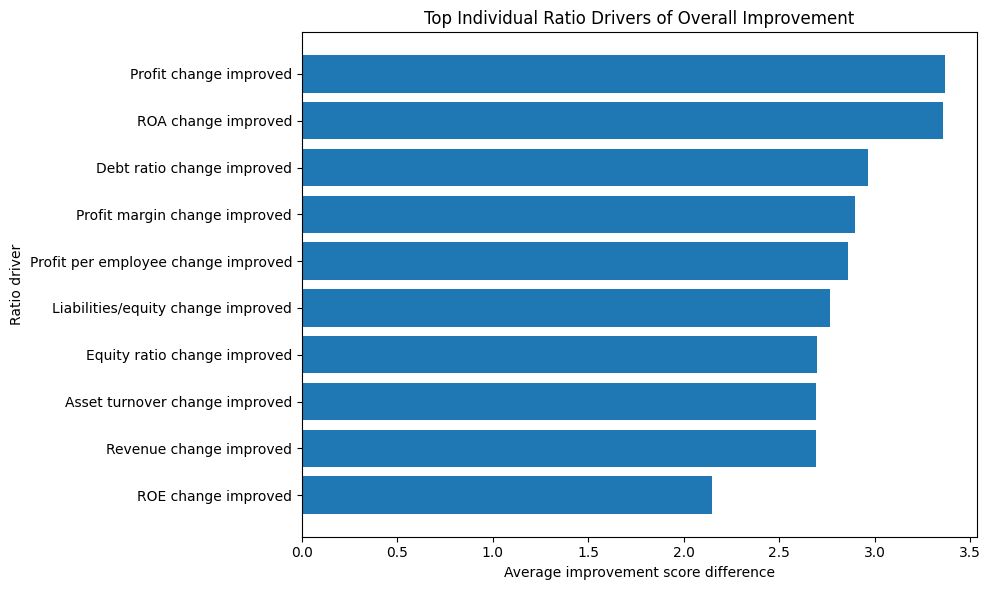

In [30]:
top_driver_plot = individual_driver_effects.head(10).copy()

plt.figure(figsize=(10, 6))
plt.barh(
    top_driver_plot["driver_flag"],
    top_driver_plot["score_difference"]
)
plt.title("Top Individual Ratio Drivers of Overall Improvement")
plt.xlabel("Average improvement score difference")
plt.ylabel("Ratio driver")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [31]:
driver_rankings.to_csv("06N_panel40_individual_ratio_correlation_ranking.csv", index=False)
individual_driver_effects.to_csv("06O_panel40_individual_driver_effects.csv", index=False)
combo_results.to_csv("06P_panel40_two_ratio_combination_effects.csv", index=False)
theory_combo_summary.to_csv("06Q_panel40_theory_based_combination_summary.csv", index=False)

print("Saved files:")
print("06N_panel40_individual_ratio_correlation_ranking.csv")
print("06O_panel40_individual_driver_effects.csv")
print("06P_panel40_two_ratio_combination_effects.csv")
print("06Q_panel40_theory_based_combination_summary.csv")

Saved files:
06N_panel40_individual_ratio_correlation_ranking.csv
06O_panel40_individual_driver_effects.csv
06P_panel40_two_ratio_combination_effects.csv
06Q_panel40_theory_based_combination_summary.csv


In [32]:
# ------------------------------------------------------------
# RATIO COMPARISON TABLE: FIRST YEAR VS LAST YEAR
# ------------------------------------------------------------

ratio_specs = {
    "Revenue": {
        "first": "Umsatz EUR_num_first",
        "last": "Umsatz EUR_num_last",
        "change": "Umsatz EUR_num_change",
        "unit": "EUR",
        "better_direction": "increase"
    },
    "Profit": {
        "first": "Gewinn EUR_num_first",
        "last": "Gewinn EUR_num_last",
        "change": "Gewinn EUR_num_change",
        "unit": "EUR",
        "better_direction": "increase"
    },
    "Profit margin": {
        "first": "profit_margin_calc_pct_first",
        "last": "profit_margin_calc_pct_last",
        "change": "profit_margin_calc_pct_change",
        "unit": "%",
        "better_direction": "increase"
    },
    "ROA": {
        "first": "roa_calc_pct_first",
        "last": "roa_calc_pct_last",
        "change": "roa_calc_pct_change",
        "unit": "%",
        "better_direction": "increase"
    },
    "ROE": {
        "first": "roe_calc_pct_first",
        "last": "roe_calc_pct_last",
        "change": "roe_calc_pct_change",
        "unit": "%",
        "better_direction": "increase"
    },
    "Asset turnover": {
        "first": "asset_turnover_calc_first",
        "last": "asset_turnover_calc_last",
        "change": "asset_turnover_calc_change",
        "unit": "x",
        "better_direction": "increase"
    },
    "Equity ratio": {
        "first": "equity_ratio_calc_pct_first",
        "last": "equity_ratio_calc_pct_last",
        "change": "equity_ratio_calc_pct_change",
        "unit": "%",
        "better_direction": "increase"
    },
    "Debt ratio": {
        "first": "debt_ratio_calc_pct_first",
        "last": "debt_ratio_calc_pct_last",
        "change": "debt_ratio_calc_pct_change",
        "unit": "%",
        "better_direction": "decrease"
    },
    "Cash/assets": {
        "first": "cash_to_assets_calc_pct_first",
        "last": "cash_to_assets_calc_pct_last",
        "change": "cash_to_assets_calc_pct_change",
        "unit": "%",
        "better_direction": "increase"
    },
    "Receivables/assets": {
        "first": "receivables_to_assets_calc_pct_first",
        "last": "receivables_to_assets_calc_pct_last",
        "change": "receivables_to_assets_calc_pct_change",
        "unit": "%",
        "better_direction": "decrease"
    },
    "Liabilities/equity": {
        "first": "liabilities_to_equity_calc_first",
        "last": "liabilities_to_equity_calc_last",
        "change": "liabilities_to_equity_calc_change",
        "unit": "x",
        "better_direction": "decrease"
    },
    "Sales per employee": {
        "first": "sales_per_employee_calc_first",
        "last": "sales_per_employee_calc_last",
        "change": "sales_per_employee_calc_change",
        "unit": "EUR",
        "better_direction": "increase"
    },
    "Profit per employee": {
        "first": "profit_per_employee_calc_first",
        "last": "profit_per_employee_calc_last",
        "change": "profit_per_employee_calc_change",
        "unit": "EUR",
        "better_direction": "increase"
    }
}

ratio_comparison_rows = []

for ratio_name, spec in ratio_specs.items():
    first_col = spec["first"]
    last_col = spec["last"]
    change_col = spec["change"]

    # Skip ratio if columns are missing
    if first_col not in change_df.columns or last_col not in change_df.columns or change_col not in change_df.columns:
        continue

    temp = change_df[[first_col, last_col, change_col]].dropna()

    if len(temp) == 0:
        continue

    if spec["better_direction"] == "increase":
        improved = (temp[change_col] > 0).sum()
        declined = (temp[change_col] < 0).sum()
    else:
        improved = (temp[change_col] < 0).sum()
        declined = (temp[change_col] > 0).sum()

    unchanged = (temp[change_col] == 0).sum()

    ratio_comparison_rows.append({
        "ratio_or_metric": ratio_name,
        "unit": spec["unit"],
        "valid_companies": len(temp),
        "first_year_median": temp[first_col].median(),
        "last_year_median": temp[last_col].median(),
        "median_change": temp[change_col].median(),
        "improved_companies": improved,
        "declined_companies": declined,
        "unchanged_companies": unchanged,
        "improved_pct": improved / len(temp) * 100,
        "better_direction": spec["better_direction"]
    })

ratio_comparison_table = pd.DataFrame(ratio_comparison_rows)

ratio_comparison_table = ratio_comparison_table.sort_values(
    ["improved_pct", "valid_companies"],
    ascending=[False, False]
)

display(ratio_comparison_table)

ratio_comparison_table.to_csv("06R_panel40_ratio_first_last_comparison_table.csv", index=False)

,ratio_or_metric,unit,valid_companies,first_year_median,last_year_median,median_change,improved_companies,declined_companies,unchanged_companies,improved_pct,better_direction
6,Equity ratio,%,36,5.896018e+01,6.219892e+01,0.0,14,8,14,38.888889,increase
9,Receivables/assets,%,36,1.468463e+01,1.156140e+01,0.0,14,7,15,38.888889,decrease
11,Sales per employee,EUR,3,8.243239e+05,8.243239e+05,0.0,1,0,2,33.333333,increase
8,Cash/assets,%,35,7.138381e+00,5.735094e+00,0.0,11,9,15,31.428571,increase
10,Liabilities/equity,x,35,3.003607e-01,1.613007e-01,0.0,11,10,14,31.428571,decrease
7,Debt ratio,%,36,2.212846e+01,1.565299e+01,0.0,10,13,13,27.777778,decrease
1,Profit,EUR,37,3.057600e+05,6.005557e+05,0.0,10,8,19,27.027027,increase
3,ROA,%,35,5.681851e+00,6.107594e+00,0.0,9,9,17,25.714286,increase
5,Asset turnover,x,12,5.807918e-02,5.807918e-02,0.0,3,0,9,25.000000,increase
0,Revenue,EUR,13,1.587229e+06,1.587229e+06,0.0,3,0,10,23.076923,increase


In [33]:
# ------------------------------------------------------------
# PROFITABILITY IMPROVEMENT TARGET
# ------------------------------------------------------------

profit_test = change_df.copy()

# Individual profitability improvement indicators
profit_test["profit_amount_improved"] = profit_test["Gewinn EUR_num_change"] > 0
profit_test["profit_margin_improved"] = profit_test["profit_margin_calc_pct_change"] > 0
profit_test["roa_improved"] = profit_test["roa_calc_pct_change"] > 0
profit_test["roe_improved"] = profit_test["roe_calc_pct_change"] > 0

# Count how many profitability indicators improved
profitability_flags = [
    "profit_amount_improved",
    "profit_margin_improved",
    "roa_improved",
    "roe_improved"
]

profit_test["profitability_improvement_score"] = profit_test[profitability_flags].sum(axis=1)

# Main target:
# Better profitability = at least 2 profitability indicators improved
profit_test["better_profitability_last_year"] = profit_test["profitability_improvement_score"] >= 2

display(
    profit_test[
        [
            "Name", "HR Amtsgericht", "Register-ID",
            "first_year", "last_year",
            "profitability_improvement_score",
            "better_profitability_last_year",
            "Gewinn EUR_num_change",
            "profit_margin_calc_pct_change",
            "roa_calc_pct_change",
            "roe_calc_pct_change"
        ]
    ].head(15)
)

,Name,HR Amtsgericht,Register-ID,first_year,last_year,profitability_improvement_score,better_profitability_last_year,Gewinn EUR_num_change,profit_margin_calc_pct_change,roa_calc_pct_change,roe_calc_pct_change
0,P & S Vermögensberatungs AG Performance & Sich...,Bayreuth,HRB 4745,2023,2024,0,False,NaN,NaN,NaN,NaN
1,DNL Prime Invest I. GmbH & Co. geschlossene In...,Bremen,HRA 30096,2021,2024,0,False,0.00,0.0,0.000000,0.000000
2,DFI Wohnen 1 geschlossene Investment GmbH & Co...,Charlottenburg (Berlin),HRA 58376 B,2022,2024,0,False,0.00,0.0,NaN,NaN
3,Alphabet Immobilien AG,Charlottenburg (Berlin),HRB 57136 B,2023,2024,0,False,0.00,NaN,0.000000,0.000000
4,JS Stahlbau GmbH,Charlottenburg (Berlin),HRB 90118 B,2023,2024,0,False,-32710.51,NaN,-18.277752,-23.273833
5,Novoferm Spare Parts GmbH,Coesfeld,HRB 13895,2023,2024,0,False,0.00,NaN,NaN,NaN
6,LaDar 1 Holding GmbH,Cottbus,HRB 15674,2023,2024,0,False,NaN,NaN,NaN,NaN
7,Thermisches Beschichtungscenter Uskovic GmbH,Dortmund,HRB 28949,2023,2024,1,False,61128.03,NaN,-0.590622,-6.777841
8,OK Asset Management GmbH,Düsseldorf,HRB 100567,2023,2024,0,False,0.00,NaN,0.000000,0.000000
9,Emscher Wassertechnik GmbH,Essen,HRB 11082,2023,2024,2,True,246494.93,NaN,0.825221,-0.244263


In [34]:
# ------------------------------------------------------------
# RULE-STYLE DRIVER ANALYSIS
# ------------------------------------------------------------

driver_rules = {
    "Revenue increased": {
        "change_col": "Umsatz EUR_num_change",
        "good_condition": "increase"
    },
    "Asset turnover increased": {
        "change_col": "asset_turnover_calc_change",
        "good_condition": "increase"
    },
    "Equity ratio increased": {
        "change_col": "equity_ratio_calc_pct_change",
        "good_condition": "increase"
    },
    "Debt ratio decreased": {
        "change_col": "debt_ratio_calc_pct_change",
        "good_condition": "decrease"
    },
    "Cash/assets increased": {
        "change_col": "cash_to_assets_calc_pct_change",
        "good_condition": "increase"
    },
    "Receivables/assets decreased": {
        "change_col": "receivables_to_assets_calc_pct_change",
        "good_condition": "decrease"
    },
    "Liabilities/equity decreased": {
        "change_col": "liabilities_to_equity_calc_change",
        "good_condition": "decrease"
    },
    "Sales per employee increased": {
        "change_col": "sales_per_employee_calc_change",
        "good_condition": "increase"
    },
    "Profit per employee increased": {
        "change_col": "profit_per_employee_calc_change",
        "good_condition": "increase"
    }
}

rule_rows = []

target = "better_profitability_last_year"

for rule_name, rule in driver_rules.items():
    col = rule["change_col"]

    if col not in profit_test.columns:
        continue

    temp = profit_test[[col, target]].dropna().copy()

    if len(temp) == 0:
        continue

    if rule["good_condition"] == "increase":
        temp["driver_improved"] = temp[col] > 0
    else:
        temp["driver_improved"] = temp[col] < 0

    group_yes = temp[temp["driver_improved"] == True]
    group_no = temp[temp["driver_improved"] == False]

    yes_success_rate = group_yes[target].mean() * 100 if len(group_yes) > 0 else np.nan
    no_success_rate = group_no[target].mean() * 100 if len(group_no) > 0 else np.nan

    rule_rows.append({
        "rule": rule_name,
        "companies_with_data": len(temp),
        "companies_where_rule_true": len(group_yes),
        "better_profitability_when_rule_true_pct": yes_success_rate,
        "better_profitability_when_rule_false_pct": no_success_rate,
        "difference_pct_points": yes_success_rate - no_success_rate,
        "successful_companies_when_rule_true": group_yes[target].sum(),
        "unsuccessful_companies_when_rule_true": len(group_yes) - group_yes[target].sum()
    })

profitability_rule_table = pd.DataFrame(rule_rows)

profitability_rule_table = profitability_rule_table.sort_values(
    "difference_pct_points",
    ascending=False
)

display(profitability_rule_table)

profitability_rule_table.to_csv("06S_panel40_profitability_rule_analysis.csv", index=False)

,rule,companies_with_data,companies_where_rule_true,better_profitability_when_rule_true_pct,better_profitability_when_rule_false_pct,difference_pct_points,successful_companies_when_rule_true,unsuccessful_companies_when_rule_true
0,Revenue increased,13,3,66.666667,10.000000,56.666667,2,1
1,Asset turnover increased,12,3,66.666667,11.111111,55.555556,2,1
8,Profit per employee increased,22,4,75.000000,22.222222,52.777778,3,1
3,Debt ratio decreased,36,10,60.000000,11.538462,48.461538,6,4
6,Liabilities/equity decreased,35,11,54.545455,8.333333,46.212121,6,5
2,Equity ratio increased,36,14,50.000000,4.545455,45.454545,7,7
5,Receivables/assets decreased,36,14,28.571429,22.727273,5.844156,4,10
4,Cash/assets increased,35,11,27.272727,25.000000,2.272727,3,8
7,Sales per employee increased,3,1,0.000000,50.000000,-50.000000,0,1


In [35]:
# ------------------------------------------------------------
# ADD INTERPRETATION COLUMN
# ------------------------------------------------------------

def interpret_rule(row):
    diff = row["difference_pct_points"]

    if pd.isna(diff):
        return "Insufficient data"
    elif diff >= 20:
        return "Strong positive association with better profitability"
    elif diff >= 10:
        return "Moderate positive association with better profitability"
    elif diff > 0:
        return "Weak positive association with better profitability"
    elif diff == 0:
        return "No visible difference"
    else:
        return "Negative or opposite association in this small sample"

profitability_rule_table["thesis_interpretation"] = profitability_rule_table.apply(
    interpret_rule,
    axis=1
)

display(profitability_rule_table)

profitability_rule_table.to_csv("06S_panel40_profitability_rule_analysis_with_interpretation.csv", index=False)

,rule,companies_with_data,companies_where_rule_true,better_profitability_when_rule_true_pct,better_profitability_when_rule_false_pct,difference_pct_points,successful_companies_when_rule_true,unsuccessful_companies_when_rule_true,thesis_interpretation
0,Revenue increased,13,3,66.666667,10.000000,56.666667,2,1,Strong positive association with better profit...
1,Asset turnover increased,12,3,66.666667,11.111111,55.555556,2,1,Strong positive association with better profit...
8,Profit per employee increased,22,4,75.000000,22.222222,52.777778,3,1,Strong positive association with better profit...
3,Debt ratio decreased,36,10,60.000000,11.538462,48.461538,6,4,Strong positive association with better profit...
6,Liabilities/equity decreased,35,11,54.545455,8.333333,46.212121,6,5,Strong positive association with better profit...
2,Equity ratio increased,36,14,50.000000,4.545455,45.454545,7,7,Strong positive association with better profit...
5,Receivables/assets decreased,36,14,28.571429,22.727273,5.844156,4,10,Weak positive association with better profitab...
4,Cash/assets increased,35,11,27.272727,25.000000,2.272727,3,8,Weak positive association with better profitab...
7,Sales per employee increased,3,1,0.000000,50.000000,-50.000000,0,1,Negative or opposite association in this small...


In [36]:
# ------------------------------------------------------------
# COMPANY-LEVEL PROFITABILITY COMPARISON TABLE
# ------------------------------------------------------------

company_profitability_table = profit_test[
    [
        "Name", "HR Amtsgericht", "Register-ID",
        "first_year", "last_year",
        "Gewinn EUR_num_first", "Gewinn EUR_num_last", "Gewinn EUR_num_change",
        "profit_margin_calc_pct_first", "profit_margin_calc_pct_last", "profit_margin_calc_pct_change",
        "roa_calc_pct_first", "roa_calc_pct_last", "roa_calc_pct_change",
        "roe_calc_pct_first", "roe_calc_pct_last", "roe_calc_pct_change",
        "profitability_improvement_score",
        "better_profitability_last_year"
    ]
].copy()

company_profitability_table = company_profitability_table.sort_values(
    ["better_profitability_last_year", "profitability_improvement_score"],
    ascending=[False, False]
)

display(company_profitability_table)

company_profitability_table.to_csv("06T_panel40_company_profitability_first_last_table.csv", index=False)

,Name,HR Amtsgericht,Register-ID,first_year,last_year,Gewinn EUR_num_first,Gewinn EUR_num_last,Gewinn EUR_num_change,profit_margin_calc_pct_first,profit_margin_calc_pct_last,profit_margin_calc_pct_change,roa_calc_pct_first,roa_calc_pct_last,roa_calc_pct_change,roe_calc_pct_first,roe_calc_pct_last,roe_calc_pct_change,profitability_improvement_score,better_profitability_last_year
15,Hutley Germany GmbH,Hannover,HRB 208030,2024,2025,-197717.44,1048721.93,1246439.37,NaN,NaN,NaN,-1.411111,8.084219,9.495330,-11.291638,3.745797e+01,4.874961e+01,3,True
19,Erwin Himmelseher Assekuranz-Vermittlung GmbH ...,Köln,HRA 12182,2023,2024,5602918.89,6680020.15,1077101.26,50.110769,54.024235,3.913466,53.081587,63.000802,9.919216,NaN,NaN,NaN,3,True
30,Be_baut GmbH & Co. KG,Osnabrück,HRA 206094,2022,2024,0.00,170374.26,170374.26,40891.458058,40891.458058,0.000000,0.000000,6.491371,6.491371,0.000000,1.703743e+06,1.703743e+06,3,True
32,Liebl Immobilien GmbH,Passau,HRB 9315,2023,2024,331510.18,600555.73,269045.55,NaN,NaN,NaN,6.090641,15.379709,9.289068,24.332363,3.059407e+01,6.261710e+00,3,True
33,NORTEG GmbH,Pinneberg,HRB 14833 PI,2023,2024,280981.34,1535392.52,1254411.18,NaN,NaN,NaN,15.905272,79.838501,63.933229,17.456588,8.338299e+01,6.592640e+01,3,True
35,eurovettura GmbH,Regensburg,HRB 16628,2022,2023,158874.43,572211.47,413337.04,NaN,NaN,NaN,1.166574,5.043514,3.876940,5.593299,1.676735e+01,1.117405e+01,3,True
9,Emscher Wassertechnik GmbH,Essen,HRB 11082,2023,2024,2448106.38,2694601.31,246494.93,NaN,NaN,NaN,9.718171,10.543392,0.825221,13.495213,1.325095e+01,-2.442626e-01,2,True
24,Dorado Grundstücksverwaltungsgesellschaft mbH,Mainz,HRB 7619,2023,2024,2311384.66,2347207.53,35822.87,60.799665,60.741487,-0.058178,6.742626,6.772908,0.030282,19.381835,1.644540e+01,-2.936432e+00,2,True
34,M & S Autohaus GmbH,Potsdam,HRB 7664,2023,2024,677599.09,724811.75,47212.66,NaN,NaN,NaN,5.681851,5.781646,0.099795,15.705133,1.438313e+01,-1.322004e+00,2,True
7,Thermisches Beschichtungscenter Uskovic GmbH,Dortmund,HRB 28949,2023,2024,150747.21,211875.24,61128.03,NaN,NaN,NaN,27.994937,27.404314,-0.590622,46.091415,3.931357e+01,-6.777841e+00,1,False


In [37]:
# ------------------------------------------------------------
# AUTO-GENERATED SUMMARY FOR THESIS NOTES
# ------------------------------------------------------------

total_companies = profit_test["company_id"].nunique()

better_profit_companies = profit_test["better_profitability_last_year"].sum()
better_profit_pct = better_profit_companies / total_companies * 100

top_rules = profitability_rule_table.head(5)

print("Same-company profitability comparison summary")
print("------------------------------------------------")
print(f"Total repeated companies analysed: {total_companies}")
print(f"Companies with better profitability in last year: {better_profit_companies} ({better_profit_pct:.1f}%)")
print("\nTop ratio conditions associated with better profitability:")
for _, row in top_rules.iterrows():
    print(
        f"- {row['rule']}: "
        f"{row['better_profitability_when_rule_true_pct']:.1f}% better profitability when condition is true "
        f"vs {row['better_profitability_when_rule_false_pct']:.1f}% when false "
        f"(difference: {row['difference_pct_points']:.1f} percentage points)"
    )

Same-company profitability comparison summary
------------------------------------------------
Total repeated companies analysed: 40
Companies with better profitability in last year: 9 (22.5%)

Top ratio conditions associated with better profitability:
- Revenue increased: 66.7% better profitability when condition is true vs 10.0% when false (difference: 56.7 percentage points)
- Asset turnover increased: 66.7% better profitability when condition is true vs 11.1% when false (difference: 55.6 percentage points)
- Profit per employee increased: 75.0% better profitability when condition is true vs 22.2% when false (difference: 52.8 percentage points)
- Debt ratio decreased: 60.0% better profitability when condition is true vs 11.5% when false (difference: 48.5 percentage points)
- Liabilities/equity decreased: 54.5% better profitability when condition is true vs 8.3% when false (difference: 46.2 percentage points)
